In [10]:
import pandas as pd
df = pd.read_csv('heart.csv')
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.shape

(1025, 14)

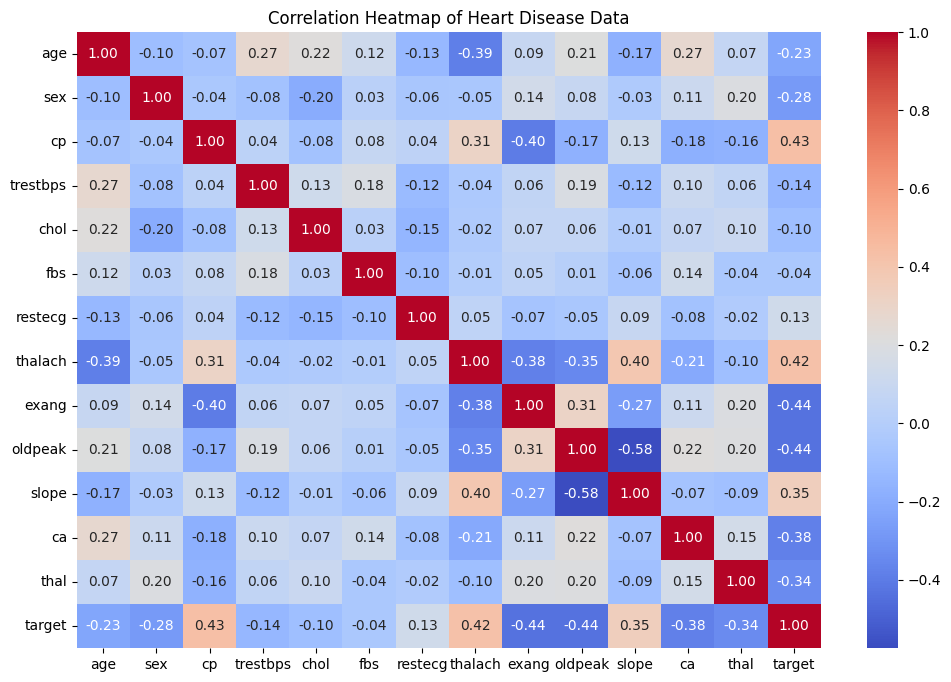

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Heart Disease Data')
plt.show()

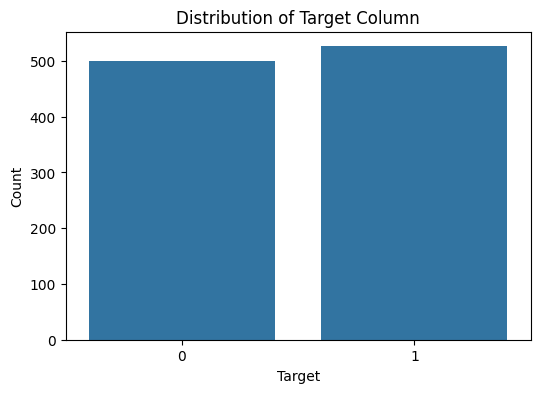

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Column')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

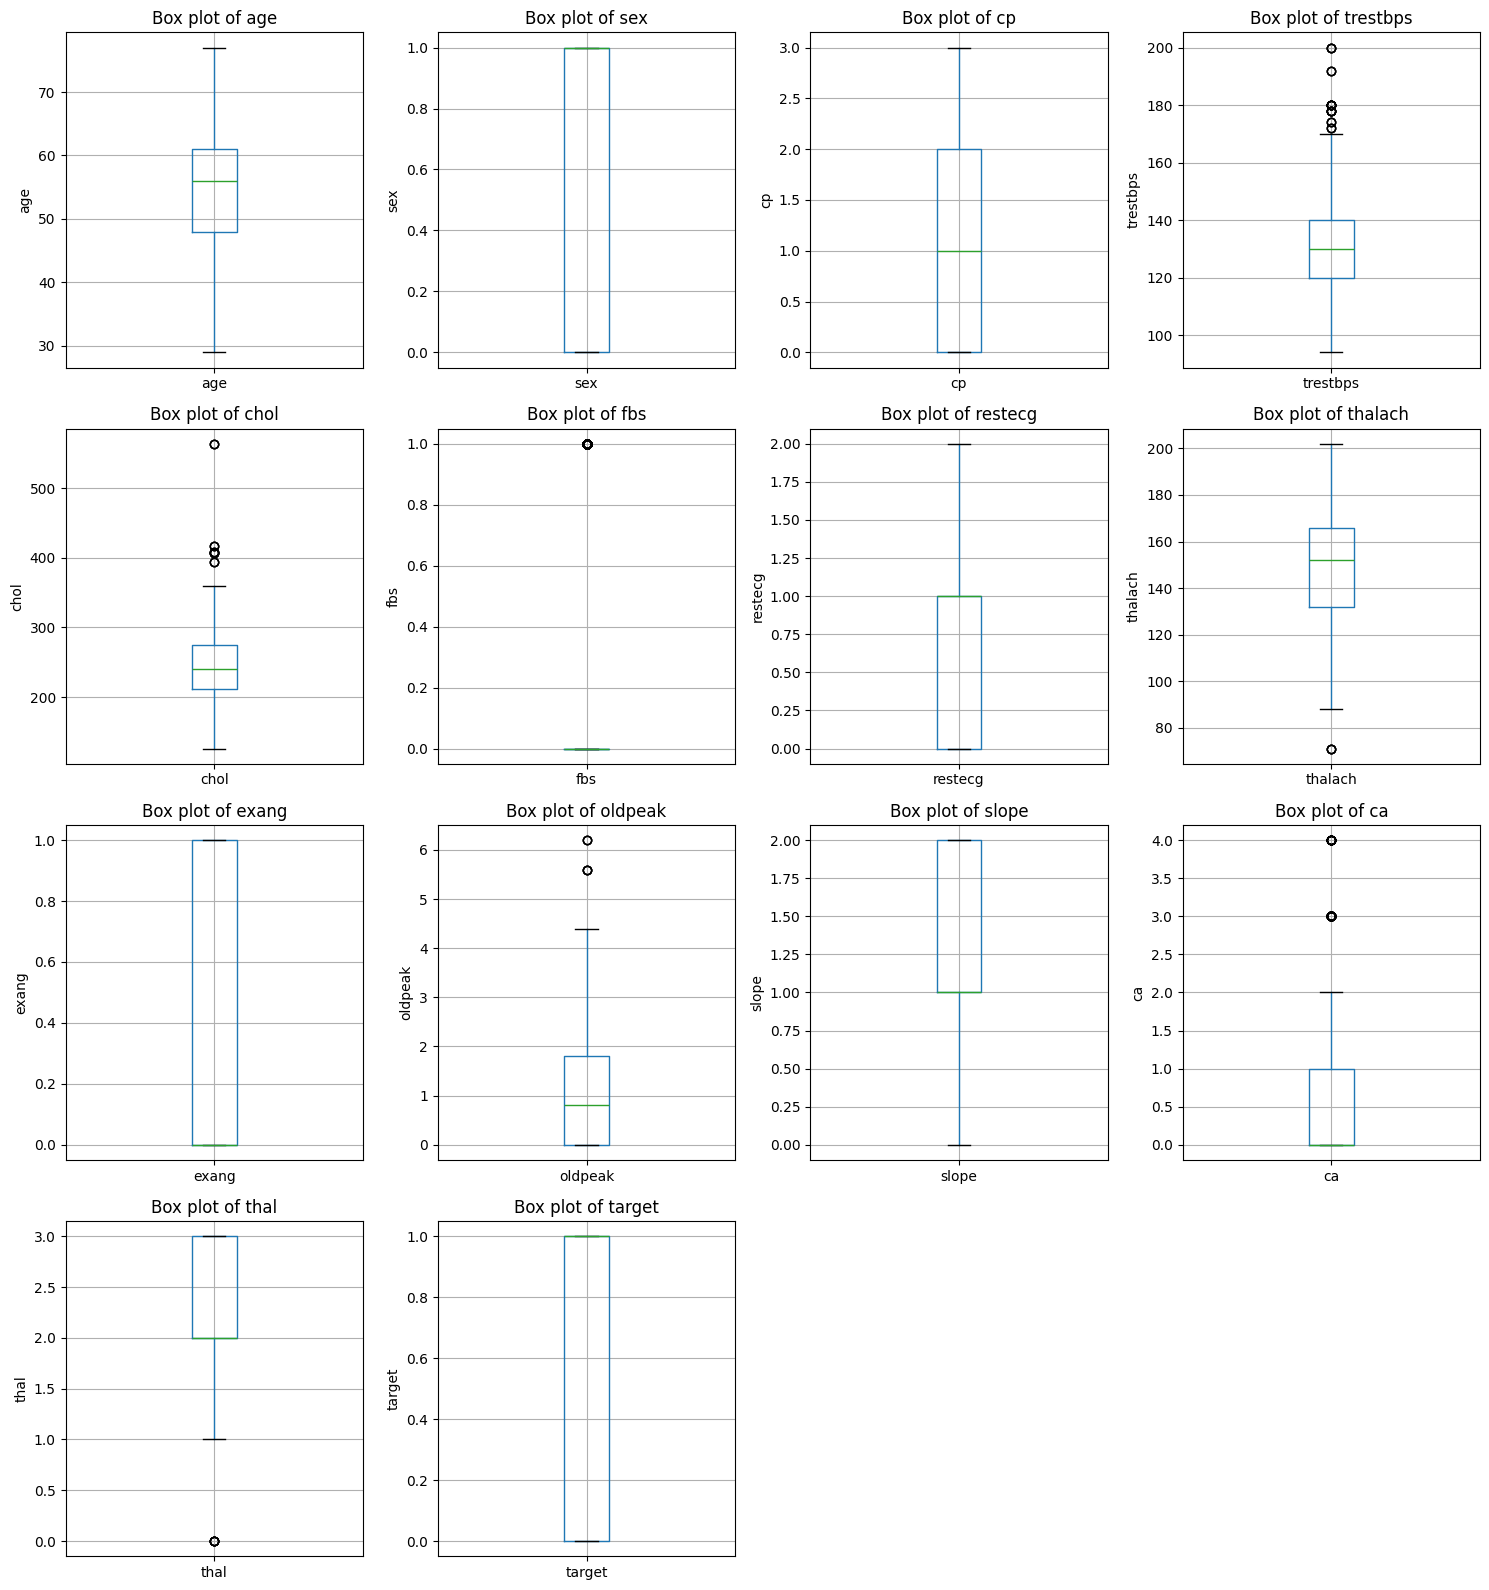

In [15]:
import matplotlib.pyplot as plt

# Determine the number of rows and columns for the subplot grid
n_cols = 4
n_rows = (len(df.columns) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(df.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    df.boxplot(column=col)
    plt.title(f'Box plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler

# Separate the target column
target = df['target']
features = df.drop('target', axis=1)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
features_scaled = scaler.fit_transform(features)

# Convert the scaled features back to a DataFrame
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)

# Combine the scaled features and the target column
df_normalized = pd.concat([features_scaled_df, target], axis=1)

display(df_normalized.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-0.268437,0.661504,-0.915755,-0.377636,-0.659332,-0.418878,0.891255,0.821321,-0.712287,-0.060888,0.995433,1.209221,1.089852,0
1,-0.158157,0.661504,-0.915755,0.479107,-0.833861,2.387330,-1.004049,0.255968,1.403928,1.727137,-2.243675,-0.731971,1.089852,0
2,1.716595,0.661504,-0.915755,0.764688,-1.396233,-0.418878,0.891255,-1.048692,1.403928,1.301417,-2.243675,-0.731971,1.089852,0
3,0.724079,0.661504,-0.915755,0.936037,-0.833861,-0.418878,0.891255,0.516900,-0.712287,-0.912329,0.995433,0.238625,1.089852,0
4,0.834359,-1.511706,-0.915755,0.364875,0.930822,2.387330,0.891255,-1.874977,-0.712287,0.705408,-0.624121,2.179817,-0.522122,0


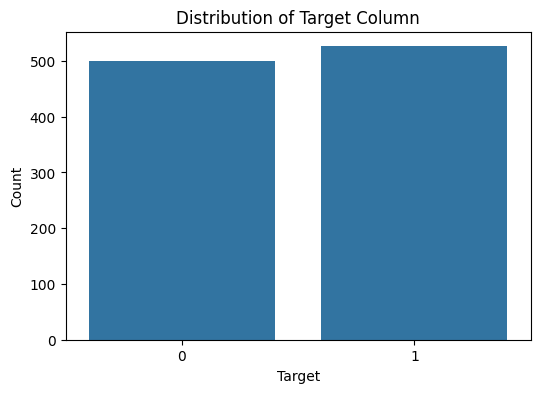

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_normalized)
plt.title('Distribution of Target Column')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y) from the normalized DataFrame
X = df_normalized.drop('target', axis=1)
y = df_normalized['target']

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (820, 13)
Shape of X_test: (205, 13)
Shape of y_train: (820,)
Shape of y_test: (205,)


In [22]:
print("Columns in X_train:", X_train.columns)

Columns in X_train: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize a dictionary to store models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
    "Gaussian Process": GaussianProcessClassifier(),
    "MLP Classifier": MLPClassifier(max_iter=1000)
}

# Dictionary to store results
results = {}

In [20]:
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store the results
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

# Print the results
for name, metrics in results.items():
    print(f"--- {name} ---")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall: {metrics['Recall']:.4f}")
    print(f"F1-score: {metrics['F1-score']:.4f}")
    print("-" * (len(name) + 6))

--- Logistic Regression ---
Accuracy: 0.7951
Precision: 0.7563
Recall: 0.8738
F1-score: 0.8108
-------------------------
--- Decision Tree ---
Accuracy: 0.9854
Precision: 1.0000
Recall: 0.9709
F1-score: 0.9852
-------------------
--- Random Forest ---
Accuracy: 0.9854
Precision: 1.0000
Recall: 0.9709
F1-score: 0.9852
-------------------
--- Gradient Boosting ---
Accuracy: 0.9317
Precision: 0.9159
Recall: 0.9515
F1-score: 0.9333
-----------------------
--- Support Vector Machine ---
Accuracy: 0.8878
Precision: 0.8509
Recall: 0.9417
F1-score: 0.8940
----------------------------
--- K-Nearest Neighbors ---
Accuracy: 0.8341
Precision: 0.8000
Recall: 0.8932
F1-score: 0.8440
-------------------------
--- Gaussian Naive Bayes ---
Accuracy: 0.8000
Precision: 0.7541
Recall: 0.8932
F1-score: 0.8178
--------------------------
--- Linear Discriminant Analysis ---
Accuracy: 0.8195
Precision: 0.7619
Recall: 0.9320
F1-score: 0.8384
----------------------------------
--- Quadratic Discriminant Analysi

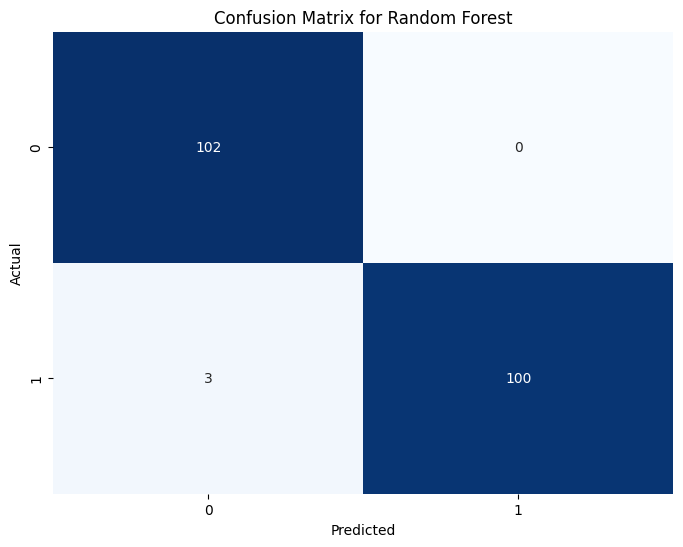

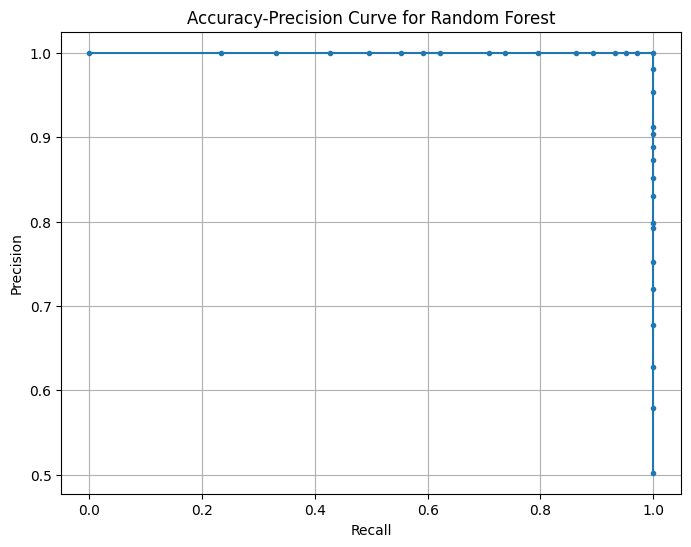

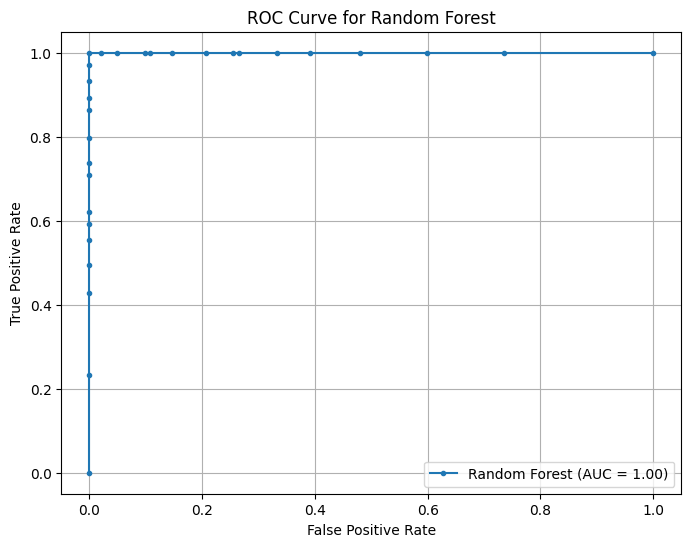

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Get the Random Forest model from the models dictionary
rf_model = models["Random Forest"]

# Make predictions and get probabilities for the test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')
plt.show()

# 2. Accuracy-Precision Curve
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Accuracy-Precision Curve for Random Forest')
plt.grid(True)
plt.show()

# 3. ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, marker='.', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import pickle

# Get the trained Random Forest model from the models dictionary
rf_model = models["Random Forest"]

# Define the filename for the pickle file
filename = 'random_forest_model.pkl'

# Open the file in binary write mode and dump the model
with open(filename, 'wb') as f:
    pickle.dump(rf_model, f)

print(f"Random Forest model saved to {filename}")

Random Forest model saved to random_forest_model.pkl


In [24]:
import pickle
import numpy as np

# Load the trained Random Forest model from the pickle file
filename = 'random_forest_model.pkl'
loaded_model = pickle.load(open(filename, 'rb'))

# Get the column names from the training data (assuming X_train is still available)
feature_names = X_train.columns

# Generate random values for each feature.
# It's important that the random data is in the same format (scaled) as the training data.
# A simple way to do this is to sample from the distribution of the training data,
# but for a quick example, we'll just generate random numbers within a reasonable range
# based on the scaled data's characteristics or just use a random normal distribution.
# For a more robust approach, consider inverse transforming or sampling from the training data itself.

# Generating random data using a normal distribution with mean 0 and std 1 (since data was scaled)
random_data = np.random.randn(1, len(feature_names))

# Convert the random data to a pandas DataFrame with the correct column names
random_df = pd.DataFrame(random_data, columns=feature_names)

# Make a prediction using the loaded model
predicted_value = loaded_model.predict(random_df)

print("Random input data (scaled):")
display(random_df)
print("\nPredicted target value:", predicted_value[0])

Random input data (scaled):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,2.670979,-1.577747,0.009051,1.597895,1.42189,-1.860735,0.790451,1.861224,-0.82907,0.345223,1.176339,0.370915,0.755565



Predicted target value: 1
